In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt

In [2]:
from google.colab import files #Upload CSV File
uploaded = files.upload()

Saving household_power_consumption.csv to household_power_consumption.csv


In [3]:
import pandas as pd

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [4]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df = df.drop(['Date', 'Time'], axis=1)

df = df.set_index('DateTime')

/tmp/ipykernel_4643/381983051.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [5]:
df = df.apply(pd.to_numeric, errors='coerce')

df = df.dropna()

In [6]:
df_hourly = df.resample('H').mean()

/tmp/ipykernel_4643/3411926171.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


In [7]:
data = df_hourly[['Global_active_power']]

In [8]:
data['hour'] = data.index.hour
data['dayofweek'] = data.index.dayofweek
data['is_weekend'] = data['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

/tmp/ipykernel_4643/3514640091.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['hour'] = data.index.hour
/tmp/ipykernel_4643/3514640091.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['dayofweek'] = data.index.dayofweek
/tmp/ipykernel_4643/3514640091.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_

In [9]:
train_size = int(len(data) * 0.8)

train = data[:train_size]
test = data[train_size:]

In [10]:
from statsmodels.tsa.arima.model import ARIMA

In [11]:
model_arima = ARIMA(train['Global_active_power'], order=(5,1,0))
model_arima_fit = model_arima.fit()

In [12]:
forecast_arima = model_arima_fit.forecast(steps=len(test))

In [13]:
from prophet import Prophet

In [14]:
prophet_df = data[['Global_active_power']].reset_index()
prophet_df.columns = ['ds', 'y']

In [15]:
m = Prophet()
m.fit(prophet_df[:train_size])

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


In [16]:
future = m.make_future_dataframe(periods=len(test), freq='H')
forecast = m.predict(future)

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [17]:
forecast_prophet = forecast['yhat'][-len(test):].values

In [18]:
data['lag1'] = data['Global_active_power'].shift(1)
data['lag2'] = data['Global_active_power'].shift(2)
data['lag3'] = data['Global_active_power'].shift(3)

data = data.dropna()

/tmp/ipykernel_4643/2761671779.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['lag1'] = data['Global_active_power'].shift(1)
/tmp/ipykernel_4643/2761671779.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['lag2'] = data['Global_active_power'].shift(2)


In [19]:
X = data[['lag1','lag2','lag3','hour','dayofweek','is_weekend']]
y = data['Global_active_power']

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [20]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [21]:
pred_xgb = model_xgb.predict(X_test)

In [22]:
def evaluate(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = sqrt(mean_squared_error(true, pred))
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}")

In [24]:
evaluate(y_test, forecast_arima, "ARIMA")
evaluate(y_test, forecast_prophet, "Prophet")
evaluate(y_test, pred_xgb, "XGBoost")

ValueError: Found input variables with inconsistent numbers of samples: [3425, 3496]

In [25]:
forecast_arima = forecast_arima[:len(y_test)]

In [26]:
evaluate(y_test.values, forecast_arima, "ARIMA")

ARIMA -> MAE: 0.719, RMSE: 1.128


In [27]:
forecast_arima = model_arima_fit.forecast(steps=len(y_test))
forecast_arima = np.array(forecast_arima)

In [28]:
forecast_prophet = forecast['yhat'].iloc[-len(y_test):].values

In [29]:
pred_xgb = pred_xgb[:len(y_test)]

In [30]:
forecast_arima = np.array(forecast_arima)[:len(y_test)]
forecast_prophet = np.array(forecast_prophet)[:len(y_test)]
pred_xgb = np.array(pred_xgb)[:len(y_test)]

evaluate(y_test.values, forecast_arima, "ARIMA")
evaluate(y_test.values, forecast_prophet, "Prophet")
evaluate(y_test.values, pred_xgb, "XGBoost")

ARIMA -> MAE: 0.719, RMSE: 1.128
Prophet -> MAE: 0.714, RMSE: 0.949
XGBoost -> MAE: 0.380, RMSE: 0.555


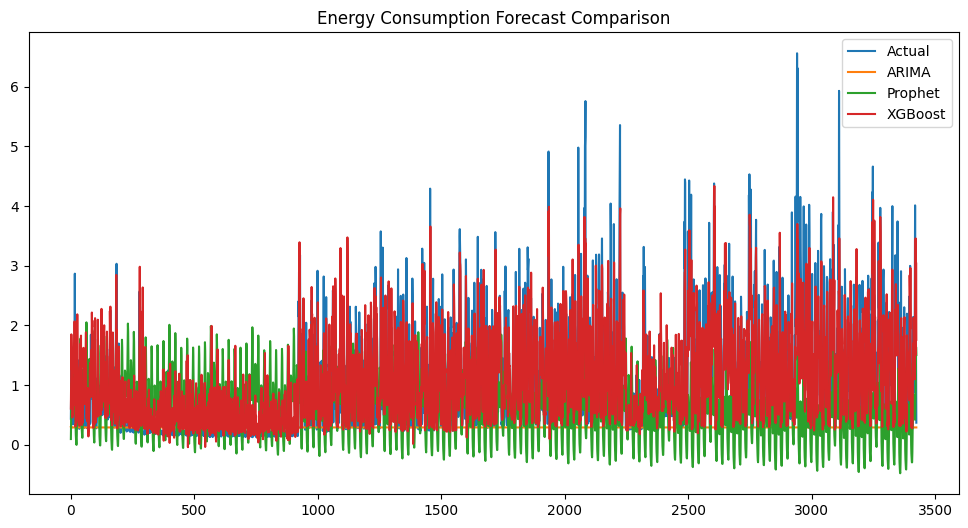

In [31]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual')
plt.plot(forecast_arima, label='ARIMA')
plt.plot(forecast_prophet, label='Prophet')
plt.plot(pred_xgb, label='XGBoost')

plt.legend()
plt.title("Energy Consumption Forecast Comparison")
plt.show()